<a href="https://colab.research.google.com/github/MokanaVijai/Bank-Marketing-campaign-Analysis-and-Term-Deposit-Subcription-Prediction-/blob/main/Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Bank Marketing Campaign Analysis and Term Deposit Subscription Prediction**

**Business problem**
     

*    The bank faces low conversion rates and high marketing costs when promoting term deposit products. The goal is to analyze customer and campaign data to identify potential subscribers and optimize future marketing efforts through predictive analytics.




**Objective**

*   Analyze customer demographics (age, job, marital status, education) and their impact on term deposit subscription.
*   Identify the financial factors (balance, housing loan, personal loan, credit default) that influence customer decisions.
*   Evaluate the effectiveness of previous marketing campaigns using
variables such as contact type, call duration, campaign contacts, previous contacts, and previous campaign outcomes.
*   Discover which customer segments have the highest probability of subscribing to a term deposit.
*   Identify the key features that most strongly influence subscription decisions.
*   Generate business insights and recommendations to improve future marketing campaigns and increase conversion rates while minimizing marketing costs.

**Dataset Information**

**Source:** UCI Machine Learning Repository
https://archive.ics.uci.edu

**Location:** Portuguese banking institution.

**Year/Timeline:** Data collected from May 2008 to November 2010 during multiple direct marketing (telephone) campaigns.

**Domain:** Banking, Finance, Direct Marketing, Customer Relationship Management (CRM).

**Expected outcome**
1.   Identify the key customer characteristics that influence term deposit subscription.
2.   Discover the most effective marketing campaign strategies and communication channels.
3. Determine the factors that positively and negatively impact customer conversion.
4. Segment customers based on their likelihood of subscribing to a term deposit.
5. Develop a predictive model that accurately identifies potential subscribers.
6. Provide actionable business recommendations to improve campaign targeting and increase conversion rates.
7. Help the bank reduce unnecessary marketing costs by focusing on high-potential customers.
8. Enable data-driven decision-making to improve the effectiveness and return on investment (ROI) of future marketing campaigns

In [ ]:
#importing Lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loading Dataset

url = "https://raw.githubusercontent.com/MokanaVijai/Bank-Marketing-dataset/main/bank_marketing.xlsx"

df = pd.read_excel(url)
print(df)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

Initial EDA

In [ ]:
# Dataset Overview
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
df.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [ ]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
#checking dataset dimentions
df.shape

(45211, 17)

In [ ]:
#checking columns attributes
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
#checking data types
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
#checking summary of datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# checking if datas are clean
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
#checking for duplicates

df.duplicated().sum()

np.int64(0)

**Data Cleaning and Data Transformation**

In [ ]:
# renaming column attributes properly
df.rename(columns = {
'marital':'Marital_Status',
'education' : 'Education',
'default': 'Credit_Default',
'balance ': 'Balance',
'housing ':'Housing_Loan',
'loan	': 'Personal_Loan',
'contact':'Contact_Type',
'day'	:'Last_Contact',
'month':	'Contact_Month',
'duration	':'Call_Duration',
'campaign ':	'Campaign_Contacts',
'pdays ': 'pdaysContacted',
'previous':	'Previous_Contacts',
'poutcome	':'Previous_Outcome',
'y'	:'Subscription'},inplace = True)

In [ ]:
df.columns

Index(['age', 'job', 'Marital_Status', 'Education', 'Credit_Default',
       'balance', 'housing', 'loan', 'Contact_Type', 'Last_Contact',
       'Contact_Month', 'duration', 'campaign', 'pdays', 'Previous_Contacts',
       'poutcome', 'Subscription'],
      dtype='object')

Imputation

In [ ]:
#checking job column
df['job'].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [ ]:
#changing unknown to most used profession
#since we have unemployed seperately
mode_job = df['job'].mode()[0]
df['job'] = df['job'].replace('unknown', mode_job)
df['job'].value_counts()

,count
job,
blue-collar,10020
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [ ]:
df

,age,job,Marital_Status,Education,Credit_Default,balance,housing,loan,Contact_Type,Last_Contact,Contact_Month,duration,campaign,pdays,Previous_Contacts,poutcome,Subscription
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,blue-collar,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
#checking Marital_Status column

df['Marital_Status'].value_counts()

,count
Marital_Status,
married,27214
single,12790
divorced,5207


In [ ]:
#checking education column
df['Education'].value_counts()

,count
Education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


In [ ]:
#imputing education column
edu_mode = df['Education'].mode()[0]
df['Education'] = df['Education'].replace('unknown',edu_mode)

df['Education'].value_counts()

,count
Education,
secondary,25059
tertiary,13301
primary,6851


In [ ]:
#checking housing cloumn
df['housing'].value_counts()

,count
housing,
yes,25130
no,20081


In [ ]:
#checking loan
df['loan'].value_counts()

,count
loan,
no,37967
yes,7244


In [ ]:
#checking contact type
df['Contact_Type'].value_counts()

,count
Contact_Type,
cellular,29285
unknown,13020
telephone,2906


In [ ]:
df.columns

Index(['age', 'job', 'Marital_Status', 'Education', 'Credit_Default',
       'balance', 'housing', 'loan', 'Contact_Type', 'Last_Contact',
       'Contact_Month', 'duration', 'campaign', 'pdays', 'Previous_Contacts',
       'poutcome', 'Subscription'],
      dtype='object')

In [ ]:
df

,age,job,Marital_Status,Education,Credit_Default,balance,housing,loan,Contact_Type,Last_Contact,Contact_Month,duration,campaign,pdays,Previous_Contacts,poutcome,Subscription
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,secondary,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,blue-collar,single,secondary,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
#checking month
df['Contact_Month'].value_counts()

,count
Contact_Month,
may,13766
jul,6895
aug,6247
jun,5341
nov,3970
apr,2932
feb,2649
jan,1403
oct,738


In [ ]:
#checking previously done outcome

df['poutcome'].value_counts()

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


"The majority (approximately 82%) of customers have an 'unknown' indicating that most customers have No Previous Marketing Campaign done or no prior campaign history. Only a small proportion had a successful or failed previous campaign."

In [ ]:
#checking Subscription column

df['Subscription'].value_counts()

,count
Subscription,
no,39922
yes,5289


**Feature Engineering**

In [ ]:
#adding extra column age group

df['Age_Group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

In [ ]:
#  Adding Balance Level
df['Balance_Level'] = pd.cut(
    df['balance'],
    bins=[-float('inf'),0,1000,5000,float('inf')],
    labels=['Negative','Low','Medium','High']
)


In [ ]:
#combiming 2 loan status and analysing with one column

df['Loan_Status'] = (
    (df['housing']=='yes') |
    (df['loan']=='yes')
).map({True:'Has Loan',False:'No Loan'})

In [ ]:
#Converting Call Duration from Seconds to Minutes
df['Call_Duration_Min'] = (df['duration']/60).round(2)

In [ ]:
#adding campaign level
df['Campaign_Level'] = pd.cut(
    df['campaign'],
    bins=[0,2,5,100],
    labels=['Low','Medium','High']
)

In [ ]:
# adding customer_type
df['Customer_Type'] = df['Previous_Contacts'].apply(
    lambda x:'Existing Customer' if x>0 else 'New Customer'
)

Final EDA

In [ ]:
#Data Frame information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                45211 non-null  int64   
 1   job                45211 non-null  object  
 2   Marital_Status     45211 non-null  object  
 3   Education          45211 non-null  object  
 4   Credit_Default     45211 non-null  object  
 5   balance            45211 non-null  int64   
 6   housing            45211 non-null  object  
 7   loan               45211 non-null  object  
 8   Contact_Type       45211 non-null  object  
 9   Last_Contact       45211 non-null  int64   
 10  Contact_Month      45211 non-null  object  
 11  duration           45211 non-null  int64   
 12  campaign           45211 non-null  int64   
 13  pdays              45211 non-null  int64   
 14  Previous_Contacts  45211 non-null  int64   
 15  poutcome           45211 non-null  object  
 16  Subs

In [ ]:
#checking datatypes
df.dtypes

,0
age,int64
job,object
Marital_Status,object
Education,object
Credit_Default,object
balance,int64
housing,object
loan,object
Contact_Type,object
Last_Contact,int64


In [ ]:
#displaying all cloumns
df.columns

Index(['age', 'job', 'Marital_Status', 'Education', 'Credit_Default',
       'balance', 'housing', 'loan', 'Contact_Type', 'Last_Contact',
       'Contact_Month', 'duration', 'campaign', 'pdays', 'Previous_Contacts',
       'poutcome', 'Subscription', 'Age_Group', 'Balance_Level', 'Loan_Status',
       'Call_Duration_Min', 'Campaign_Level', 'Customer_Type'],
      dtype='object')

In [ ]:
#for better visulization copying orginal df in df_plot for analysis
df_plot = df.copy()

#using df_plot for analysis
df_plot['poutcome'] = df_plot['poutcome'].replace({
    'unknown': 'No Previous Campaign ',
    'failure': 'Previous Campaign Failed',
    'success': 'Previous Campaign Successful',
    'other': 'Other Outcome'
})

**Statistical analysis & Visualizations**


MEASURE OF CENTRAL TENDENCy

In [ ]:
df

,age,job,Marital_Status,Education,Credit_Default,balance,housing,loan,Contact_Type,Last_Contact,...,pdays,Previous_Contacts,poutcome,Subscription,Age_Group,Balance_Level,Loan_Status,Call_Duration_Min,Campaign_Level,Customer_Type
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,-1,0,unknown,no,51-60,Medium,Has Loan,4.35,Low,New Customer
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,-1,0,unknown,no,41-50,Low,Has Loan,2.52,Low,New Customer
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,-1,0,unknown,no,31-40,Low,Has Loan,1.27,Low,New Customer
3,47,blue-collar,married,secondary,no,1506,yes,no,unknown,5,...,-1,0,unknown,no,41-50,Medium,Has Loan,1.53,Low,New Customer
4,33,blue-collar,single,secondary,no,1,no,no,unknown,5,...,-1,0,unknown,no,31-40,Low,No Loan,3.30,Low,New Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,...,-1,0,unknown,yes,51-60,Low,No Loan,16.28,Medium,New Customer
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,...,-1,0,unknown,yes,60+,Medium,No Loan,7.60,Low,New Customer
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,...,184,3,success,yes,60+,High,No Loan,18.78,Medium,Existing Customer
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,...,-1,0,unknown,no,51-60,Low,No Loan,8.47,Medium,New Customer


In [ ]:
# Numerical Columns
num_cols = ['age', 'balance', 'duration']

# Mean
print("Mean")
print(df['age'].mean())

# Median
print("\nMedian")
print(df['age'].median())

# Mode
print("\nMode")
print(df['age'].mode().iloc[0])


central_tendency = pd.DataFrame({
    'Mean': df['age'].mean(),
    'Median': df['age'].median(),
    'Mode': df['age'].mode()[0]
}, index=[0])

print(central_tendency)

Mean
40.93621021432837

Median
39.0

Mode
32
       Mean  Median  Mode
0  40.93621    39.0    32


In [ ]:
# Summary statistics
summary_stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': df[num_cols].mode().iloc[0],
    'Variance': df[num_cols].var(),
    'Std Deviation': df[num_cols].std(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
}).round(2)

summary_stats

,Mean,Median,Mode,Variance,Std Deviation,Skewness,Kurtosis
age,40.94,39.0,32,112.76,10.62,0.68,0.32
balance,1362.27,448.0,0,9270598.95,3044.77,8.36,140.75
duration,258.16,180.0,124,66320.57,257.53,3.14,18.15


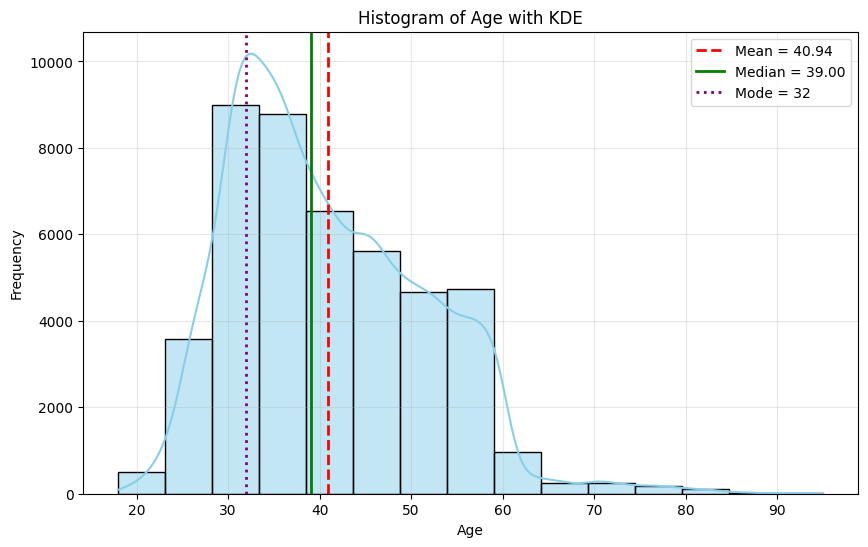

Mean: 40.94
Median: 39.0
Mode: 32


In [ ]:
# Calculate statistics
mean_age = df['age'].mean()
median_age = df['age'].median()
mode_age = df['age'].mode()[0]

# Plot
plt.figure(figsize=(10,6))

sns.histplot(df['age'], bins=15, kde=True,
             color='skyblue', edgecolor='black')

# Mean, Median, Mode
plt.axvline(mean_age, color='red', linestyle='--',
            linewidth=2, label=f'Mean = {mean_age:.2f}')

plt.axvline(median_age, color='green', linestyle='-',
            linewidth=2, label=f'Median = {median_age:.2f}')

plt.axvline(mode_age, color='purple', linestyle=':',
            linewidth=2, label=f'Mode = {mode_age}')

# Labels
plt.title("Histogram of Age with KDE")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Print statistics
print("Mean:", round(mean_age,2))
print("Median:", median_age)
print("Mode:", mode_age)



**Interpretation**
*Distribution Shape
Shape: Positively Skewed (Right-Skewed)

Interpretation:
A skewness of 0.68 indicates a moderately positive skew, meaning most individuals are younger to middle-aged, with relatively fewer older individuals creating the right tail.

Most ages are concentrated between approximately 30 and 50 years, with the highest frequency around 30–40 years.

Interpretation:
A kurtosis value close to 0 indicates the distribution is fairly similar to a normal distribution in terms of tail heaviness, with only slightly heavier tails.

Observation
The distribution is unimodal with a single prominent peak.
The relationship Mean (40.94) > Median (39) > Mode (32) confirms a positively skewed distribution.
Most observations lie between 30 and 50 years, while a few higher-age observations extend the right tail.
Key Insight
The majority of individuals are young to middle-aged adults.
Older age groups (above about 60 years) are comparatively fewer and contribute to the positive skew.
The distribution is not perfectly normal but only moderately skewed,
Interpretation

The dataset mainly represents individuals in the 30–50-year age range. Since the mean is influenced by higher-age values, the median (39 years) is a better measure of the central tendency for describing a typical individual's age.


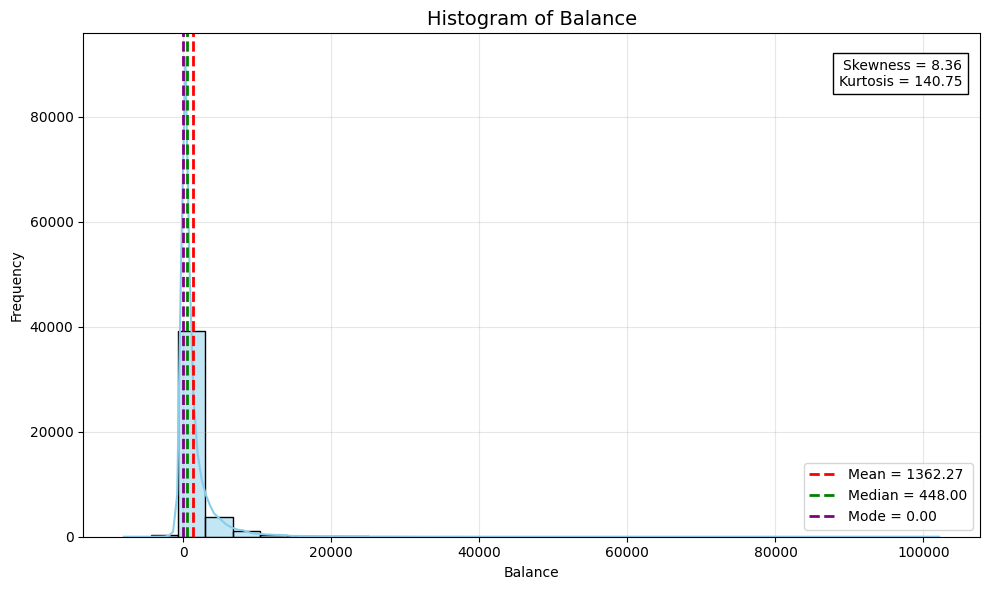

Column: balance
Distribution Shape : Right Skewed
Skewness           : 8.36 (Right Skewed)
Kurtosis           : 140.75
Most values lie between : 72.00 and 1428.00
Standard Deviation : 3044.77
IQR                : 1356.00


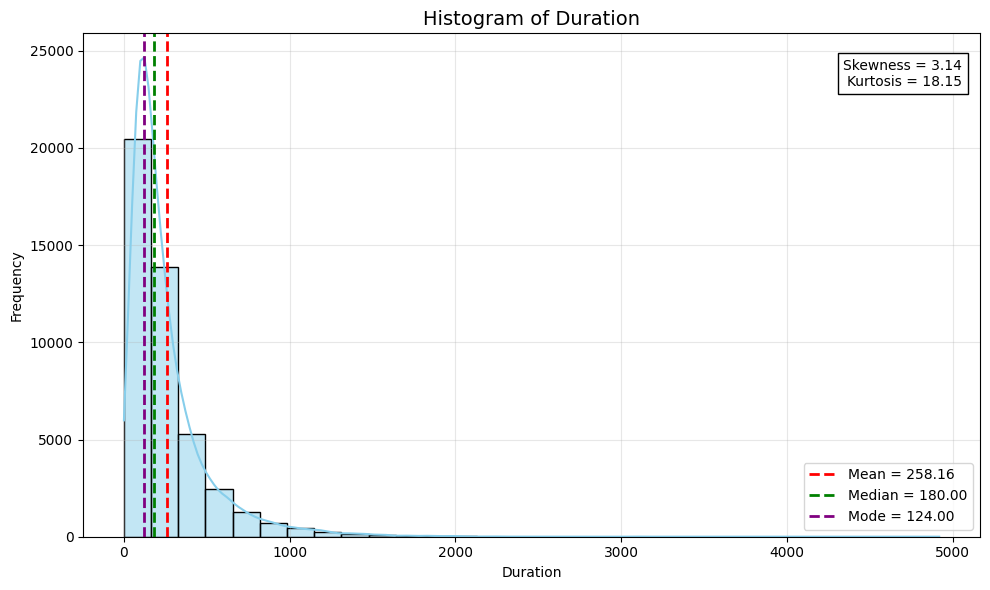

Column: duration
Distribution Shape : Right Skewed
Skewness           : 3.14 (Right Skewed)
Kurtosis           : 18.15
Most values lie between : 103.00 and 319.00
Standard Deviation : 257.53
IQR                : 216.00


In [ ]:
# Numerical Columns
num_cols = ['balance', 'duration']

for col in num_cols:

    # Statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    std_val = df[col].std()
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    # Distribution Shape
    if abs(skew_val) < 0.5:
        shape = "Approximately Normal"
    elif skew_val > 0.5:
        shape = "Right Skewed"
    else:
        shape = "Left Skewed"

    # Plot
    plt.figure(figsize=(10,6))

    sns.histplot(df[col],
                 bins=30,
                 kde=True,
                 color='skyblue',
                 edgecolor='black')

    # Mean, Median, Mode
    plt.axvline(mean_val,
                color='red',
                linestyle='--',
                linewidth=2,
                label=f'Mean = {mean_val:.2f}')

    plt.axvline(median_val,
                color='green',
                linestyle='--',
                linewidth=2,
                label=f'Median = {median_val:.2f}')

    plt.axvline(mode_val,
                color='purple',
                linestyle='--',
                linewidth=2,
                label=f'Mode = {mode_val:.2f}')

    # Skewness & Kurtosis Annotation
    plt.text(
        0.98,
        0.95,
        f"Skewness = {skew_val:.2f}\nKurtosis = {kurt_val:.2f}",
        transform=plt.gca().transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(facecolor='white', edgecolor='black')
    )

    plt.title(f'Histogram of {col.capitalize()}', fontsize=14)
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Concentration Range
    lower = q1
    upper = q3

    # Interpretation
    print("="*80)
    print(f"Column: {col}")
    print("="*80)
    print(f"Distribution Shape : {shape}")

    if skew_val > 0:
        direction = "Right Skewed"
    elif skew_val < 0:
        direction = "Left Skewed"
    else:
        direction = "Symmetric"

    print(f"Skewness           : {skew_val:.2f} ({direction})")
    print(f"Kurtosis           : {kurt_val:.2f}")
    print(f"Most values lie between : {lower:.2f} and {upper:.2f}")
    print(f"Standard Deviation : {std_val:.2f}")
    print(f"IQR                : {iqr:.2f}")




Observation:
- The distribution of 'balance' is right skewed.
- The middle 50% of observations lie between 72.00 and 1428.00.
- Standard deviation of 3044.77 indicates the overall variability.

Key Insight:
- The feature is highly skewed, indicating the presence of extreme values.

Interpretation:
- The histogram helps understand how 'balance' values are distributed and whether outliers or skewness exist.

Recommendation:
- Consider log or Box-Cox transformation before machine learning.

**Group by analysis**

In [ ]:
# Variance and Standard Deviation
dispersion = pd.DataFrame({
    'Variance': df[num_cols].var(),
    'Standard Deviation': df[num_cols].std()
})

dispersion

,Variance,Standard Deviation
balance,9.270599e+06,3044.765829
duration,6.632057e+04,257.527812


In [ ]:
#to Identify which occupations have the highest subscription rate.
df.groupby('job')['Subscription'].value_counts().unstack(fill_value=0)

Subscription,no,yes
job,,
admin.,4540,631
blue-collar,9278,742
entrepreneur,1364,123
housemaid,1131,109
management,8157,1301
retired,1748,516
self-employed,1392,187
services,3785,369
student,669,269


In [ ]:
#percentage distribution of subscription status within each Balance Level.
balance_subscription = (df.groupby('Balance_Level')['Subscription']
                          .value_counts(normalize=True)
                          .mul(100)
                          .unstack()
                          .round(2))
balance_subscription

/tmp/ipykernel_398/2798568673.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_subscription = (df.groupby('Balance_Level')['Subscription']


Subscription,no,yes
Balance_Level,,
Negative,93.10,6.90
Low,89.10,10.90
Medium,84.67,15.33
High,84.50,15.50


In [ ]:
#previous campaign outcome has the highest success rate
(df.groupby('poutcome')['Subscription']
   .value_counts(normalize=True)
   .mul(100)
   .unstack())

Subscription,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


In [ ]:
#contact type generated the highest number of subscriptions
df[df['Subscription']=='yes']['Contact_Type'].value_counts()

,count
Contact_Type,
cellular,4369
unknown,530
telephone,390


In [ ]:
#Contact Month × Contact Type × Subscription
pd.crosstab([df['Last_Contact'],
             df['Contact_Month']],
             df['Subscription'])

Subscription                 no  yes
Last_Contact Contact_Month          
1            apr             34   13
             aug              1    0
             feb              6    3
             jul             63   10
             jun             67   39
...                         ...  ...
31           dec              1    0
             jul            559   21
             mar              8    6
             may              6    1
             oct              1    3

[318 rows x 2 columns]

**Visualizations**



**Univariate Analysis**

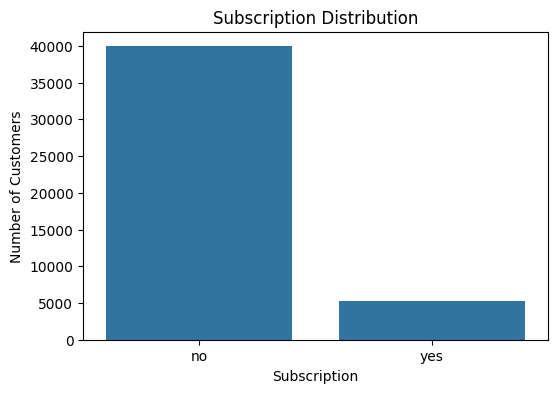

In [ ]:
#Subscription Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Subscription')
plt.title('Subscription Distribution')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:**
*   This count plot shows the distribution of customers based on whether they subscribed to the term deposit.

**Insights:**
*   The dataset is highly imbalanced, with approximately 88% of customers not subscribing and only about 12% subscribing to the term deposit.
*   This imbalance indicates that successful subscriptions are relatively rare in the dataset.
*   This suggests that the marketing campaign had a relatively low conversion rate.
*   Overall, the chart suggests that customer subscription is uncommon, which should be considered when building predictive models, as class imbalance may affect model performance.

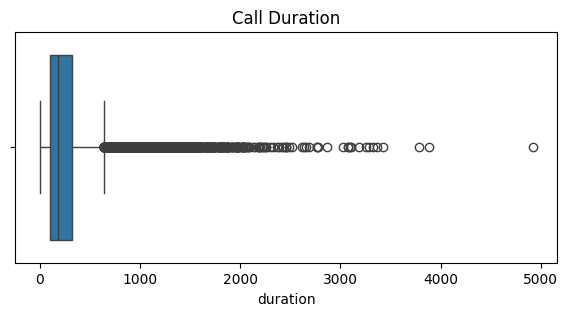

In [ ]:
#Call Duration
plt.figure(figsize=(7,3))
sns.boxplot(x=df['duration'])
plt.title('Call Duration')
plt.show()

**Interpretation:**
*   This box plot shows the distribution of Call Duration and highlights the presence of outliers.

**Insights:**
*   Most calls are short.
*   A few calls are much longer, indicating potential outliers.
Longer calls may reflect greater customer engagement.
*   The distribution of call duration is highly right-skewed, with most calls having relatively short durations.
*   A large number of outliers are present, representing customers with unusually long call durations.
*   The median call duration is much lower than the maximum duration, indicating that only a small proportion of calls last for a long time.


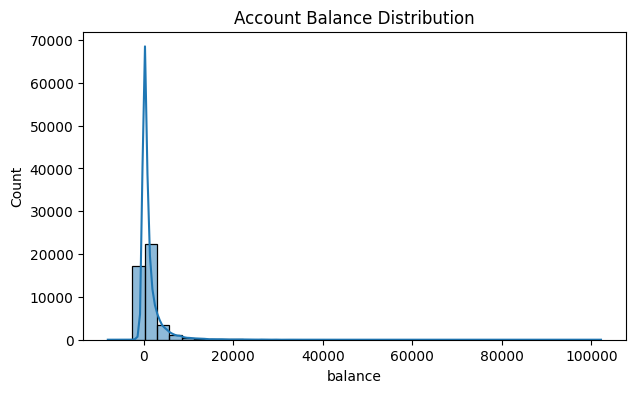

In [ ]:
#Balance Distribution
plt.figure(figsize=(7,4))
sns.histplot(df['balance'], bins=40, kde=True)
plt.title('Account Balance Distribution')
plt.show()

**Interpretation:**
*   This histogram with a density curve shows the distribution of customers' account balances.

**Insights:**
*   The distribution is highly right-skewed, with most customers having low or near-zero account balances.
*   A small number of customers have very high account balances, creating a long right tail in the distribution.
*   The presence of these high-value outliers increases the overall spread of the balance data.
*   High-value customers may require personalized marketing strategies.
*   the chart indicates that the majority of customers maintain relatively low balances, while only a few customers hold exceptionally high balances.

**Bivariate Analysis**

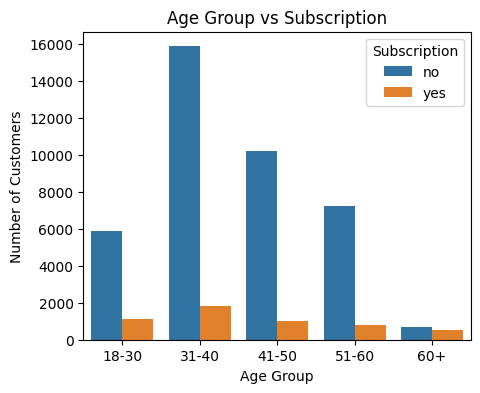

In [ ]:
#Compare subscription behavior across age groups.
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x='Age_Group',
    hue='Subscription'
)

plt.title('Age Group vs Subscription')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Subscription')
plt.show()

**Interpretation:**
*   This bar chart compares the number of customers who subscribed (yes) and did not subscribe (no) to the term deposit across different age groups.

**Insights:**
*   The 31–40 age group has the largest customer base and records the highest number of subscriptions.
*   Across all age groups, the number of non-subscribers is significantly higher than the number of subscribers.
*   The 18–30 and 41–50 age groups show a moderate number of subscriptions, while the 51–60 group has fewer.
*   Although the 60+ age group has the fewest customers, it still includes a noticeable proportion of subscribers.
*   Overall, middle-aged customers (31–40) contribute the most subscriptions, but the majority of customers in every age group did not subscribe to the term deposit.

<Axes: xlabel='count', ylabel='job'>

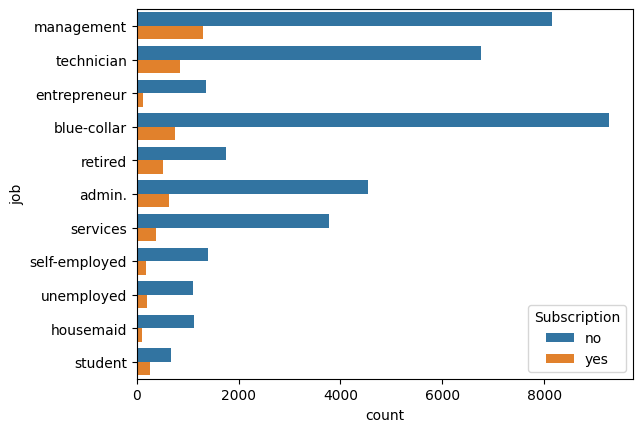

In [ ]:
#occupations with higher subscription counts.
sns.countplot(y='job', hue='Subscription', data=df)

**Interpretation:**
*   This horizontal count plot compares the number of customers who
subscribed (yes) and did not subscribe (no) to the term deposit across different job categories.

**Insights:**
*   Blue-collar, Management, and Technician are the largest customer groups, but most customers in these categories did not subscribe.
*   Management has the highest number of subscribers among all job categories, followed by Technician and Blue-collar.
*   Students and Retired customers have fewer total customers but show a relatively higher proportion of subscriptions compared to several other job groups.
*   the chart indicates that subscription behavior varies across occupations, although the majority of customers in every job category chose not to subscribe.

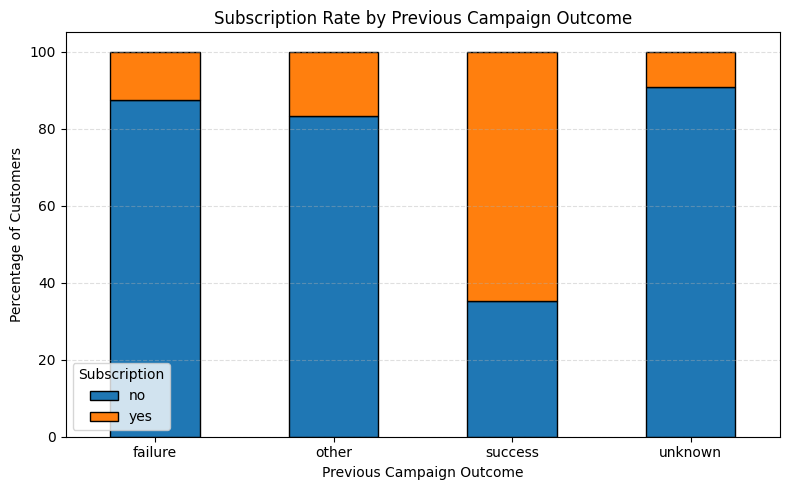

In [ ]:
#subcription level by previous outcome
previous_sub = (
    pd.crosstab(df['poutcome'], df['Subscription'], normalize='index') * 100
).round(1)

previous_sub.plot(kind='bar',
                  stacked=True,
                  figsize=(8,5),
                  edgecolor='black')

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Observation**
Failure – The customer was contacted in a previous campaign, but did not subscribe.

Success – The customer was contacted in a previous campaign and did subscribe.

Other – The previous campaign outcome was known, but it was neither success nor failure. It may include outcomes that don't fit the main categories (such as an inconclusive or different result).

Unknown – There was no previous campaign information available. Usually, this means the customer was never contacted before

**Business Interpretation**
Customers who have responded positively in the past are more likely to respond positively again. This highlights the importance of using historical campaign data when selecting customers for future marketing campaigns

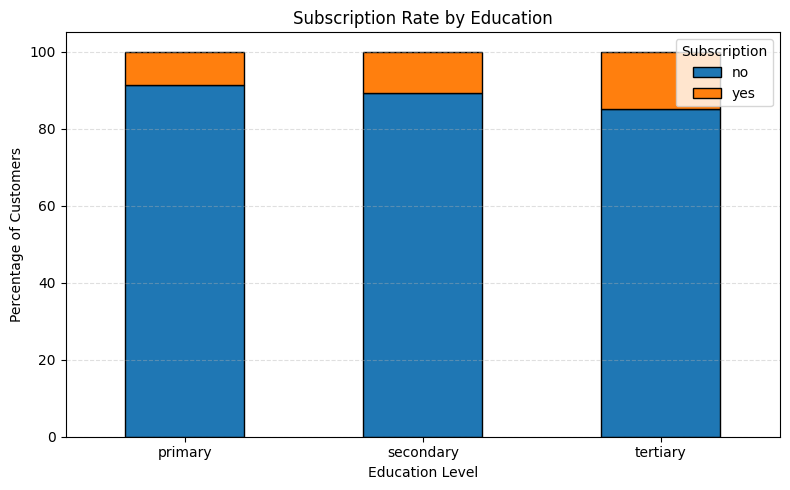

In [ ]:
# Calculate subscription percentage
education_sub = (
    pd.crosstab(df['Education'], df['Subscription'], normalize='index') * 100
).round(1)

education_sub.plot(kind='bar',
                   stacked=True,
                   figsize=(8,5),
                   edgecolor='black')

plt.title("Subscription Rate by Education")
plt.xlabel("Education Level")
plt.ylabel("Percentage of Customers")
plt.legend(title="Subscription")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Observation**
The subscription rate differs across education levels.
Some education groups have a higher proportion of customers who subscribed, while others have a larger percentage of non-subscribers.
**Key Insight**
Education level influences customer response to marketing campaigns, indicating differences in financial awareness and investment preferences.
**Business Interpretation**
Customers with certain education levels may be more receptive to term deposit offers. Understanding these differences allows the bank to create more targeted and relevant marketing campaigns.

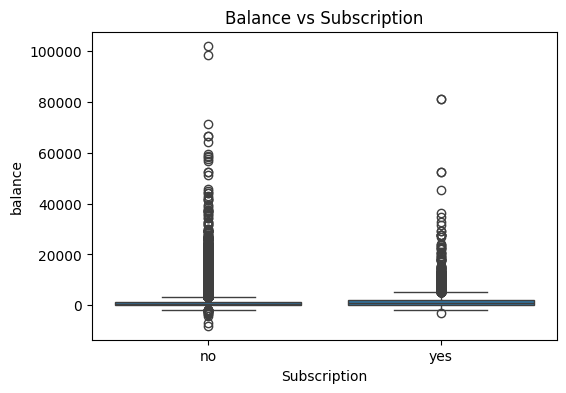

In [ ]:
#Balance Level vs Subscription

plt.figure(figsize=(6,4))
sns.boxplot(x='Subscription', y='balance', data=df)
plt.title('Balance vs Subscription')
plt.show()

**Interpretation:**
*   This grouped bar chart compares the number of customers who subscribed (yes) and did not subscribe (no) to the term deposit across different age groups.

**Insights:**
*   The 31–40 age group has the highest number of customers and also the highest number of subscriptions.
*   In every age group, the number of customers who did not subscribe is significantly higher than those who subscribed.
The 60+ age group has the fewest customers, but it still contains both subscribers and non-subscribers.
*   The chart indicates that middle-aged customers (31–40 and 41–50) form the largest customer base and contribute the highest number of subscriptions, although the majority of customers across all age groups chose not to subscribe.

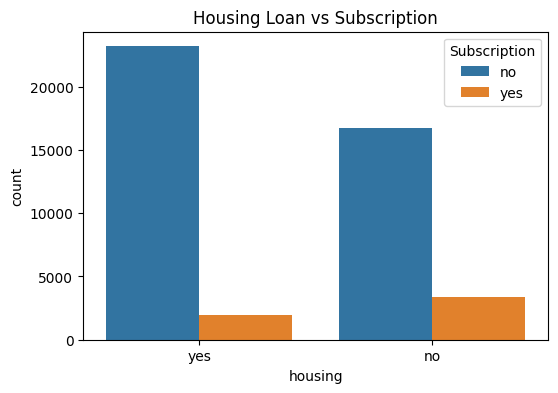

In [ ]:
#Housing Loan vs Subscription
plt.figure(figsize=(6,4))
sns.countplot(x='housing', hue='Subscription', data=df)
plt.title('Housing Loan vs Subscription')
plt.show()

**Interpretation:**
*  This bar chart compares the number of customers who subscribed (yes) and did not subscribe (no) to the term deposit based on whether they have a housing loan.

**Insights:**

*  Customers without a housing loan have a higher number of term deposit subscriptions compared to customers who have a housing loan.
*  Among both housing loan groups, the majority of customers did not subscribe to the term deposit.
*  Customers with a housing loan show a lower subscription count, suggesting they may be less likely to invest in a term deposit.



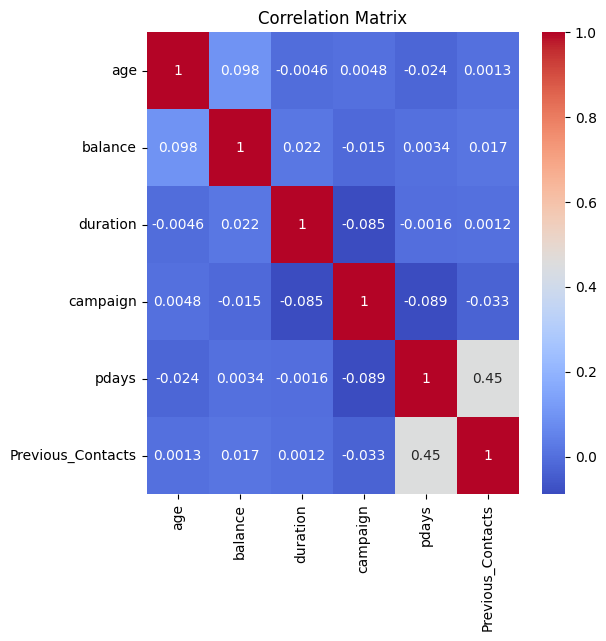

In [ ]:
#correlation matrix for numerical column
num_cols = ['age','balance','duration','campaign','pdays','Previous_Contacts']

plt.figure(figsize=(6,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Interpretation:**
*  This heatmap shows the correlation between the numerical features in the dataset.
* Correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little or no relationship.

**Insights:**
*  Most numerical features have very weak correlations, indicating they are largely independent of one another.
* Pdays and Previous_Contacts show the strongest positive correlation (0.45), suggesting that customers contacted previously tend to have fewer days since their last contact.
* Campaign has a slight negative correlation with Pdays (-0.089) and Duration (-0.085), but the relationships are weak.
* Low multicollinearity indicates that each feature contributes distinct information.

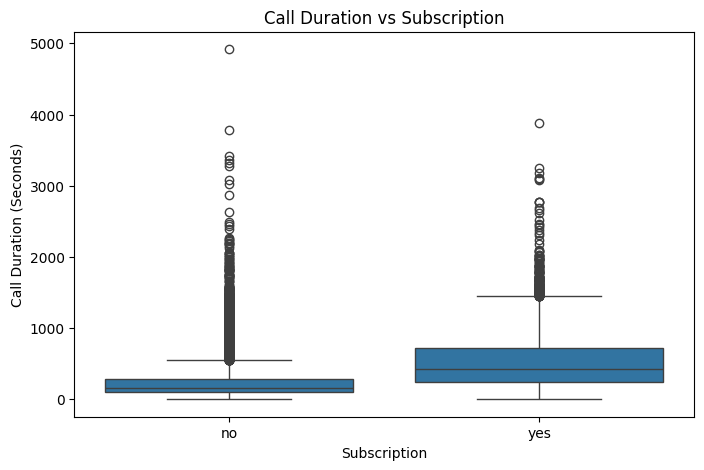

In [ ]:
#call duration with subscription
plt.figure(figsize=(8,5))
sns.boxplot(x='Subscription', y='duration', data=df)

plt.title('Call Duration vs Subscription')
plt.xlabel('Subscription')
plt.ylabel('Call Duration (Seconds)')
plt.show()

**Interpretation**
This box plot compares the distribution of call duration between customers who subscribed (yes) and those who did not (no).
The features used are Subscription and duration.
If the median and overall distribution of the yes group are higher, it indicates that customers who subscribed generally had longer conversations.
This suggests that longer customer interactions may increase the likelihood of subscribing to a term deposit.

**Multivariate Analysis**

<Figure size 200x200 with 0 Axes>

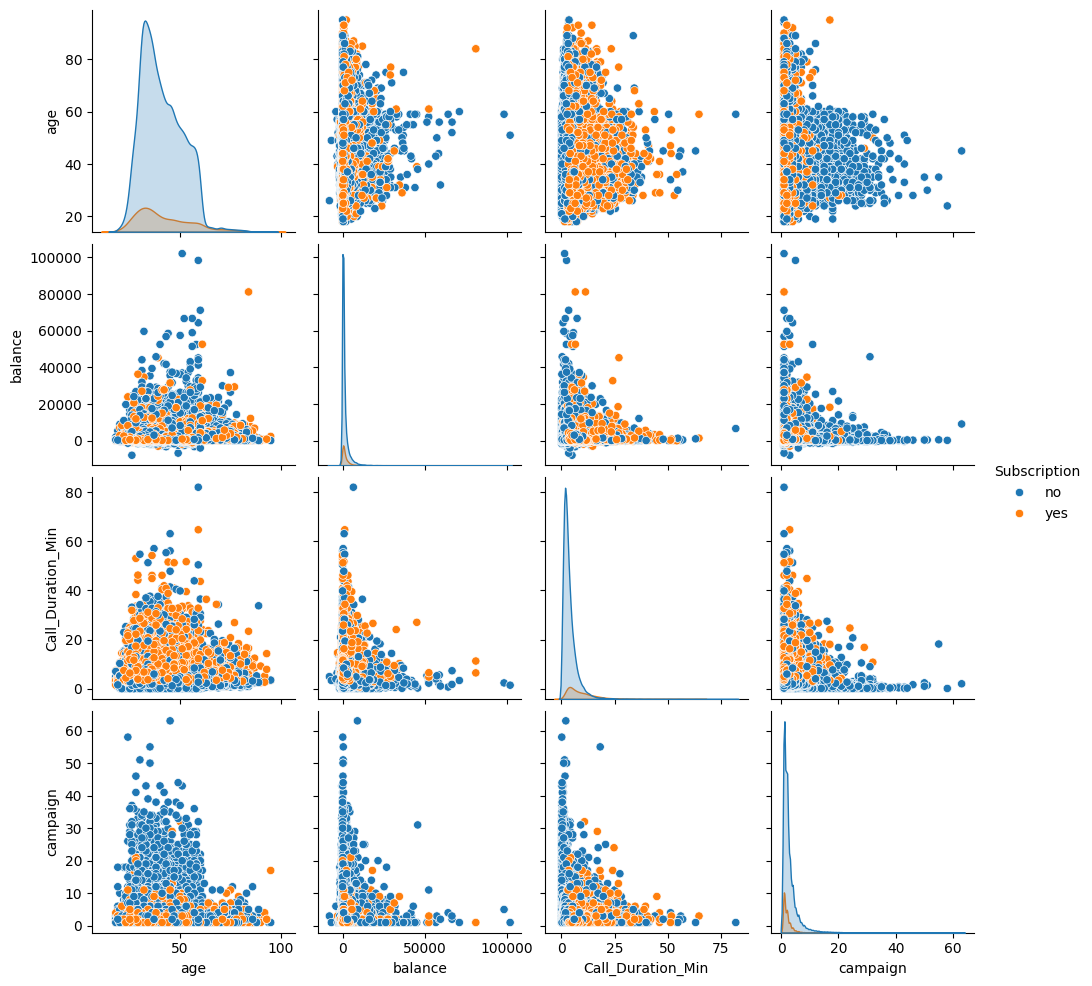

In [ ]:
#pair plot pairwise relationships among numerical variables
plt.figure(figsize = (2,2))
sns.pairplot(
    df[['age',
        'balance',
        'Call_Duration_Min',
        'campaign',
        'Subscription']],
    hue='Subscription'
)

**Interpretation:**
*   This pair plot visualizes the relationships between the numerical
features (Age, Balance, Call Duration, and Campaign) and compares them based on Subscription (yes and no).
*   The diagonal plots show the distribution of each variable, while the scatter plots show relationships between feature pairs.

**Insights:**
*   Customers with longer call durations are more likely to subscribe, as the yes class appears more frequently at higher call durations.
*   Age and Balance do not show a strong relationship with subscription, with subscribers and non-subscribers distributed across most values.
*   Campaign is right-skewed, and customers contacted fewer times tend to have a higher number of subscriptions than those contacted repeatedly.
*   Balance is also highly right-skewed with several outliers, but high account balance alone does not guarantee subscription.
*   Call Duration appears to be the strongest indicator of subscription, while Age, Balance, and Campaign have weaker relationships with the target variable.

Text(0.5, 1.0, 'Subscription Rate by Age Group and Balance Level')

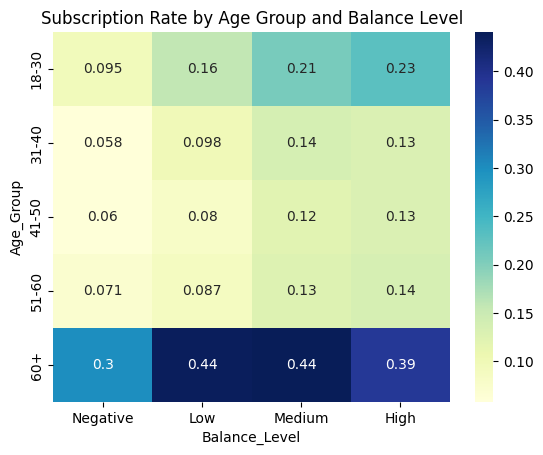

In [ ]:
#Heatmap of Age Group vs Balance Level vs Subscription Rate
pivot = pd.crosstab(df['Age_Group'],
                    df['Balance_Level'],
                    values=(df['Subscription']=='yes'),
                    aggfunc='mean')

sns.heatmap(pivot,
            annot=True,
            cmap='YlGnBu')
plt.title('Subscription Rate by Age Group and Balance Level')

**Interpretation:**
*   This heatmap displays the average term deposit subscription rate for customers across different age groups and balance levels.
*   The values inside each cell represent the proportion of customers who subscribed.
*   Darker-colored cells indicate higher subscription rates, while lighter-colored cells indicate lower rates.
*   This analysis helps identify which combinations of age and account balance are associated with greater customer interest in term deposits.


**Documentation, Insights & Presentation**

**Summary of Findings:**

*  The Bank Marketing Analysis project examined customer demographics, financial information, and marketing campaign details to understand the factors influencing term deposit subscriptions.
*  The analysis showed that customer behavior is influenced by multiple factors rather than a single attribute.
*   Exploratory Data Analysis revealed important patterns in customer age, account balance, call duration, contact methods, loan status, and previous campaign outcomes.
*  Feature engineering and statistical analysis further improved customer segmentation and business understanding.
*  Overall, the project provides valuable insights that can help the bank target potential customers more effectively and improve the success rate of future marketing campaigns.

**Key Insights :**

*  The subscription target variable is highly imbalanced, with significantly more customers not subscribing than subscribing.
*  Call duration is one of the strongest indicators of customer subscription, with longer conversations generally resulting in higher subscription rates.
*  Customers who previously responded successfully to marketing campaigns are more likely to subscribe again.
*  Customer characteristics such as age, balance, occupation, education, and loan status influence subscription behavior, although their impact varies across different customer segments.
*  Feature engineering (Age Group, Balance Level, Campaign Level, Customer Type, and Call Duration in Minutes) made customer segmentation more meaningful and improved business interpretation.

**Types of Analysis**
1. Descriptive Analysis
Descriptive analysis summarizes historical data.
Analysis Performed:
•	Analyzed the distribution of Age, Account Balance, and Call Duration.
•	Examined the distribution of term deposit subscriptions.
•	Created Age Group, Balance Level, and Campaign Level to summarize customer characteristics.
________________________________________
2. Diagnostic Analysis
Diagnostic analysis explains why certain outcomes occurred.
Analysis Performed:
•	Analyzed the relationship between Age Group and Subscription.
•	Studied how Occupation, Account Balance, Housing Loan, and Call Duration influence subscription.
•	Used a heatmap to identify how Age Group and Balance Level together affect subscription rates.
________________________________________
3. Predictive Analysis
Predictive analysis helps forecast future outcomes.
Analysis Performed:
•	Identified key features such as Call Duration, Balance, Age Group, and Housing Loan for predicting term deposit subscriptions.
•	Prepared the dataset for building a subscription prediction model.
________________________________________
4. Prescriptive Analysis
Prescriptive analysis recommends actions based on insights.
Suggested Actions:
•	Target customers with higher account balances for future campaigns.
•	Focus marketing efforts on customer segments with higher subscription rates.
•	Increase customer engagement through longer and more effective calls.
•	Design personalized campaigns based on age group, occupation, and loan status.
•	Prioritize customers with successful previous campaign outcomes.
•	Focus on effective communication strategies to improve customer engagement.


**Future Enhancement**
1. Expand the Dataset
Use a larger or more recent banking dataset to capture changing customer behavior and improve the reliability of insights.
Include additional customer attributes such as income, credit score, transaction history, and digital banking activity for deeper analysis.
2. Improve Data Quality
Reduce the number of unknown or missing values through better data collection and validation.
4. Extend to Predictive Analytics
Build machine learning models such as Logistic Regression, Decision Tree, Random Forest, or XGBoost to predict whether a customer is likely to subscribe to a term deposit.
Compare model performance using metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC.
5. Enhance Customer Segmentation
Apply clustering techniques (e.g., K-Means) to identify customer segments with similar characteristics.
6. Focus on customers with higher subscription probability.
7. Support Data-Driven Decision Making
Integrate predictive insights into the bank's marketing strategy to prioritize high-potential customers.
8. Improve campaign targeting management by Doing camp on IT employees about financial awareness


**Expected outcome**

1.Identify the key customer characteristics that influence term deposit subscription.
  Answer:
  The analysis shows that customer characteristics such as age, account balance, previous campaign outcome, and call duration influence term deposit subscription.
  Customers with higher balances, successful previous campaign outcomes, and longer call durations are more likely to subscribe.
________________________________________
2. Discover the most effective marketing campaign strategies and communication channels.
Answer:
The cellular communication channel performed better than telephone or unknown contact methods. Customers contacted through cellular communication and those with longer call durations showed higher subscription rates, indicating that personalized and effective communication improves campaign success.
________________________________________
3. Determine the factors that positively and negatively impact customer conversion.
Answer:
Positive Factors:
•	Longer call duration
•	Previous campaign success
•	Higher account balance
•	No housing loan
Negative Factors:
•	Previous campaign failure
•	Unknown previous campaign outcome
•	Short call duration
•	Repeated unsuccessful campaign contacts
________________________________________
4. Segment customers based on their likelihood of subscribing to a term deposit.
Answer:
Customers can be segmented into:
•	High Potential: Previous campaign success, high balance, longer call duration.
•	Medium Potential: Moderate balance with average call duration.
•	Low Potential: Previous campaign failure, unknown campaign outcome, low balance, and very short call duration.
________________________________________
5. Develop a predictive model that accurately identifies potential subscribers.
Answer:
A predictive model can be developed using machine learning algorithms such as Logistic Regression, Decision Tree, Random Forest, or XGBoost.
These models use customer demographics, financial information, and campaign details to predict the likelihood of subscription.
________________________________________
6. Provide actionable business recommendations to improve campaign targeting and increase conversion rates.
Answer:
•	Focus campaigns on high-potential customers.
•	Improve call quality to achieve longer customer engagement.
•	Prioritize customers with successful previous campaign history.
•	Personalize marketing strategies based on customer characteristics.
________________________________________
7. Help the bank reduce unnecessary marketing costs by focusing on high-potential customers.
Answer:
By identifying customers who are more likely to subscribe, the bank can avoid contacting low-potential customers repeatedly.
This reduces marketing costs, saves employee time, and increases campaign efficiency.
________________________________________
8. Enable data-driven decision-making to improve the effectiveness and return on investment (ROI) of future marketing campaigns.
Answer:
The analysis provides insights into customer behavior and campaign performance, allowing the bank to make informed decisions. Targeting the right customers through effective communication channels improves conversion rates and increases the ROI of future marketing campaigns.


**Conclusion**
  
  This project successfully analyzed the Bank Marketing dataset using Python and performed data preprocessing, feature engineering, and exploratory data analysis. Various visualizations helped identify key factors influencing term deposit subscriptions, including age group, account balance, occupation, housing loan status, and call duration. The insights obtained can support banks in improving marketing strategies, targeting the right customers, and increasing subscription rates.
